(18)=
# Chapter 18: Ordinary Differential Equations (Not the final version)

**Topics Covered:**
- What an ODE is and how to think about it
- Euler's method: building intuition by stepping forward manually
- `scipy.integrate.solve_ivp`: Python's general-purpose ODE solver
- Systems of ODEs: multiple coupled equations
- Stiff ODEs and choosing the right solver
- Chemical engineering application: batch reactor and CSTR dynamics

## Motivation: Why Do We Need ODEs?

Many real processes evolve **over time** — not just at steady state. When a quantity changes continuously, the governing equation usually involves a **derivative**:

$$
\frac{dC_A}{dt} = -k\,C_A
$$

This says: *the rate of change of concentration equals minus a rate constant times the current concentration.* It is a **first-order ODE**.

Some familiar ChE examples:

| Physical situation | ODE |
|--------------------|-----|
| First-order batch reaction | $\frac{dC_A}{dt} = -k C_A$ |
| Newton's law of cooling | $\frac{dT}{dt} = -\frac{UA}{mC_p}(T - T_\infty)$ |
| Tank draining (Torricelli) | $\frac{dh}{dt} = -\frac{A_o}{A_t}\sqrt{2gh}$ |
| CSTR start-up | $\frac{dC_A}{dt} = \frac{F}{V}(C_{A0} - C_A) - k C_A$ |

In all these cases we know the *rate of change* and want to find the *trajectory* — how the quantity evolves from an **initial condition** at $t=0$.

Analytically, the first equation gives $C_A(t) = C_{A0}\,e^{-kt}$. But most real ODEs have no closed-form solution. We need numerical methods.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

(18.1)=
## 18.1 What is an ODE?

An **ordinary differential equation (ODE)** is an equation that relates an unknown function to its own **rate of change** (its derivative). Instead of asking "what is the value of $y$?", an ODE asks "what is the *rule* by which $y$ changes?"

Compare these two types of equations:

| Type | Example | What it tells you |
|------|---------|-------------------|
| Algebraic equation | $2x + 3 = 7$ | The value of $x$ directly |
| ODE | $\frac{dC_A}{dt} = -k\,C_A$ | How $C_A$ *changes* over time |

The ODE does **not** tell you $C_A$ directly — it tells you the slope at every point. To recover the actual trajectory $C_A(t)$, you must **integrate** starting from a known starting point.

### 18.1.1 The Standard Form

The general first-order ODE is written:

$$
\frac{dy}{dt} = f(t,\, y), \qquad y(t_0) = y_0
$$

- $y(t)$ — the **unknown function** we want to find (concentration, temperature, height, …)
- $f(t, y)$ — a **known expression** for the rate of change (the right-hand side of the ODE)
- $y(t_0) = y_0$ — the **initial condition**: the value of $y$ at the starting time $t_0$

The initial condition is essential. Without it, an ODE has infinitely many solutions — one for every possible starting value. With it, the solution is unique.

> **Analogy:** Imagine you know a car's velocity at every instant. That alone doesn't tell you *where* the car is — you also need to know where it started. The initial condition is that starting position.

### 18.1.2 Order of an ODE

The **order** of an ODE is the highest derivative that appears:

| Order | Form | Example |
|-------|------|---------|
| 1st order | $\frac{dy}{dt} = f(t, y)$ | First-order reaction: $\frac{dC_A}{dt} = -k C_A$ |
| 2nd order | $\frac{d^2y}{dt^2} = f\!\left(t, y, \frac{dy}{dt}\right)$ | Spring-mass: $m\ddot{x} = -kx$ |
| $n$th order | involves $\frac{d^n y}{dt^n}$ | Higher-order dynamics |

**Why first-order matters most:** Any higher-order ODE can always be rewritten as a *system* of first-order ODEs by introducing new variables for each derivative. For example:

$$
\frac{d^2x}{dt^2} = -\omega^2 x
\quad\longrightarrow\quad
\begin{cases}
\frac{dx}{dt} = v \\
\frac{dv}{dt} = -\omega^2 x
\end{cases}
$$

This means knowing how to solve first-order systems is enough to handle *any* ODE.

### 18.1.3 Solving an ODE = Integration

Rearranging the standard form:

$$
dy = f(t,\, y)\, dt
\quad\Longrightarrow\quad
y(t) = y_0 + \int_{t_0}^{t} f(\tau,\, y(\tau))\, d\tau
$$

This is just integration — but the catch is that $f$ depends on $y(\tau)$, which is the very thing we are trying to find. This is why we need **numerical methods**: they break the circularity by marching forward in small steps, using the current known value of $y$ to estimate the next one.

### 18.1.4 Verifying an Analytical Solution

For simple ODEs, an analytical solution exists. Let's verify the exponential decay solution:

$$
\frac{dC_A}{dt} = -k C_A, \quad C_A(0) = C_{A0}
\quad\Longrightarrow\quad
C_A(t) = C_{A0}\,e^{-kt}
$$

To verify: differentiate the proposed solution and check it satisfies the ODE:

$$
\frac{d}{dt}\left[C_{A0}\,e^{-kt}\right] = -k\,C_{A0}\,e^{-kt} = -k\,C_A(t) \checkmark
$$

dC = -kC dt

1/C dC = -k dt

ln C = -kt + A
C = exp(-kt + A) = exp(A)exp(-kt) = B exp(-kt)

at t=0, C = B = C0

C = C0 exp(-kt)

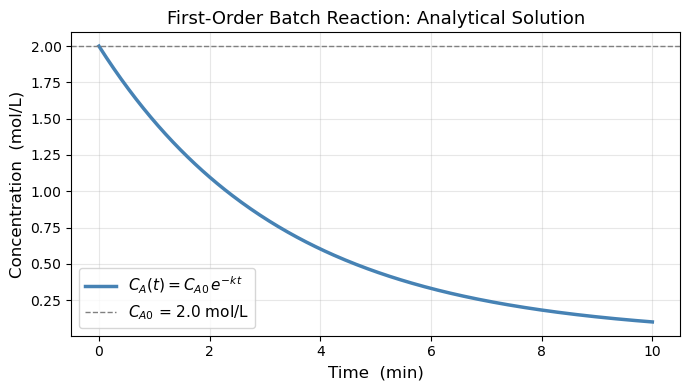

At t = 5 min:  C_A = 0.4463 mol/L


In [2]:
k    = 0.3          # 1/min — first-order rate constant
C_A0 = 2.0          # mol/L — initial concentration

t = np.linspace(0, 10, 300)
C_A_exact = C_A0 * np.exp(-k * t)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, C_A_exact, 'steelblue', linewidth=2.5, label=r'$C_A(t) = C_{A0}\,e^{-kt}$')
ax.axhline(C_A0, color='gray', linestyle='--', linewidth=1, label=f'$C_{{A0}}$ = {C_A0} mol/L')
ax.set_xlabel('Time  (min)', fontsize=12)
ax.set_ylabel('Concentration  (mol/L)', fontsize=12)
ax.set_title('First-Order Batch Reaction: Analytical Solution', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At t = 5 min:  C_A = {C_A0 * np.exp(-k*5):.4f} mol/L")

(18.2)=
## 18.2 Euler's Method

$$
\frac{dy}{dt} = f(t,\, y), \qquad y(t_0) = y_0
$$

Euler's method produces approximate solution values at evenly-spaced times:

$$
t_0,\quad t_1 = t_0 + h,\quad t_2 = t_0 + 2h,\quad \ldots
$$

where $h$ is the **step size**. Starting from the known initial condition $y_0 = y(t_0)$, each new value is computed from the previous one using the ODE right-hand side:

$$
\begin{aligned}
y_1 &= y_0 + h\,f(t_0,\, y_0) \\
y_2 &= y_1 + h\,f(t_1,\, y_1) \\
&\vdots \\
y_n &= y_{n-1} + h\,f(t_{n-1},\, y_{n-1})
\end{aligned}
$$

The idea is simple: at each point we know the slope $f(t_{n-1}, y_{n-1})$, so we take a straight-line step of length $h$ in the direction of that slope.

The visualization below shows the first two steps in detail — with $h$, the step $h\,f(t_0, y_0)$, and the error of $y_1$ all labeled.

> **Think about it:** Looking at the picture, what would you do to reduce the error?

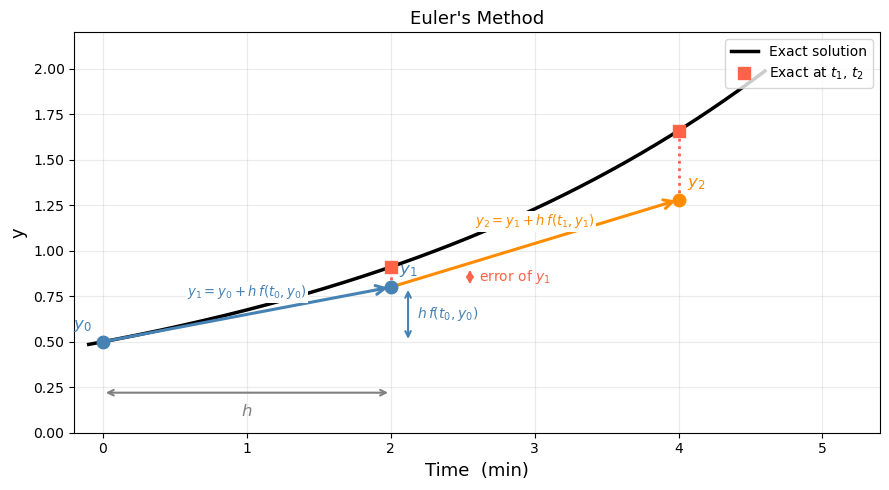

y0 = 0.5000   (exact: 0.5000)
y1 = 0.8000   (exact: 0.9111,  error = 0.1111)
y2 = 1.2800   (exact: 1.6601,  error = 0.3801)


In [3]:
# ── Euler's method: two-step annotated diagram ───────────────────────────────
import numpy as np
from matplotlib import pyplot as plt
k  = 0.3
y0 = 0.5
t0 = 0.0
h  = 2.0   # large so labels are clearly visible

def f(t, y):  return k * y           # ODE right-hand side  (growing)
def exact(t): return y0 * np.exp(k * t)

# --- compute the two Euler steps ---
t1, y1 = t0 + h,     y0 + h * f(t0, y0)
t2, y2 = t0 + 2*h,   y1 + h * f(t1, y1)

# --- exact curve ---
t_fine = np.linspace(-0.1, t0 + 2*h + 0.6, 400)
y_fine = exact(t_fine)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t_fine, y_fine, 'k-', lw=2.5, label='Exact solution', zorder=3)

# ── Step 1: y0 → y1 ──────────────────────────────────────────────────────────
slope0 = f(t0, y0)                          # f(t0, y0)
step0  = h * slope0                         # h·f(t0, y0)  — vertical rise

# tangent arrow y0 → y1
ax.annotate('', xy=(t1, y1), xytext=(t0, y0),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.2,
                            mutation_scale=16))

# label the Euler points
ax.plot(t0, y0, 'o', color='steelblue', ms=9, zorder=5)
ax.plot(t1, y1, 'o', color='steelblue', ms=9, zorder=5)
ax.text(t0 - 0.08, y0 + 0.07, '$y_0$', fontsize=12, ha='right', color='steelblue')
ax.text(t1 + 0.06, y1 + 0.07, '$y_1$', fontsize=12, color='steelblue')

# ── h bracket (horizontal) ────────────────────────────────────────────────────
bracket_y = y0 - 0.28
ax.annotate('', xy=(t1, bracket_y), xytext=(t0, bracket_y),
            arrowprops=dict(arrowstyle='<->', color='gray', lw=1.5))
ax.text((t0 + t1)/2, bracket_y - 0.13, '$h$',
        ha='center', fontsize=12, color='gray')

# ── h·f(t0,y0) bracket (vertical) ────────────────────────────────────────────
bx = t1 + 0.12
ax.annotate('', xy=(bx, y1), xytext=(bx, y0),
            arrowprops=dict(arrowstyle='<->', color='steelblue', lw=1.5))
ax.text(bx + 0.06, (y0 + y1)/2,
        r'$h\,f(t_0, y_0)$', fontsize=10, color='steelblue', va='center')

# ── error of y1 ──────────────────────────────────────────────────────────────
y1_exact = exact(t1)
ex = t1 + 0.55
ax.plot([t1, t1], [y1, y1_exact], ':', color='tomato', lw=2, zorder=4)
ax.plot(t1, y1_exact, 's', color='tomato', ms=8, zorder=5,
        label='Exact at $t_1$, $t_2$')
ax.annotate('', xy=(ex, y1_exact), xytext=(ex, y1),
            arrowprops=dict(arrowstyle='<->', color='tomato', lw=1.5))
ax.text(ex + 0.06, (y1 + y1_exact)/2,
        'error of $y_1$', fontsize=10, color='tomato', va='center')

# ── Step 2: y1 → y2 ──────────────────────────────────────────────────────────
ax.annotate('', xy=(t2, y2), xytext=(t1, y1),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=2.2,
                            mutation_scale=16))
ax.plot(t2, y2, 'o', color='darkorange', ms=9, zorder=5)
ax.plot(t2, exact(t2), 's', color='tomato', ms=8, zorder=5)
ax.text(t2 + 0.06, y2 + 0.07, '$y_2$', fontsize=12, color='darkorange')

# error of y2 (dotted line only, unlabeled to keep figure clean)
ax.plot([t2, t2], [y2, exact(t2)], ':', color='tomato', lw=2, zorder=4)

# ── step labels inside arrows ────────────────────────────────────────────────
ax.text((t0+t1)/2, (y0+y1)/2 + 0.10,
        r'$y_1 = y_0 + h\,f(t_0,y_0)$',
        fontsize=9.5, color='steelblue', ha='center',
        bbox=dict(fc='white', ec='none', pad=1))
ax.text((t1+t2)/2, (y1+y2)/2 + 0.10,
        r'$y_2 = y_1 + h\,f(t_1,y_1)$',
        fontsize=9.5, color='darkorange', ha='center',
        bbox=dict(fc='white', ec='none', pad=1))

# ── axes and legend ───────────────────────────────────────────────────────────
ax.set_xlabel('Time  (min)', fontsize=13)
ax.set_ylabel('y', fontsize=13)
ax.set_title("Euler's Method",
             fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-0.2, t0 + 2*h + 1.4)
ax.set_ylim(0.0, 2.2)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

print(f"y0 = {y0:.4f}   (exact: {exact(t0):.4f})")
print(f"y1 = {y1:.4f}   (exact: {exact(t1):.4f},  error = {abs(y1 - exact(t1)):.4f})")
print(f"y2 = {y2:.4f}   (exact: {exact(t2):.4f},  error = {abs(y2 - exact(t2)):.4f})")

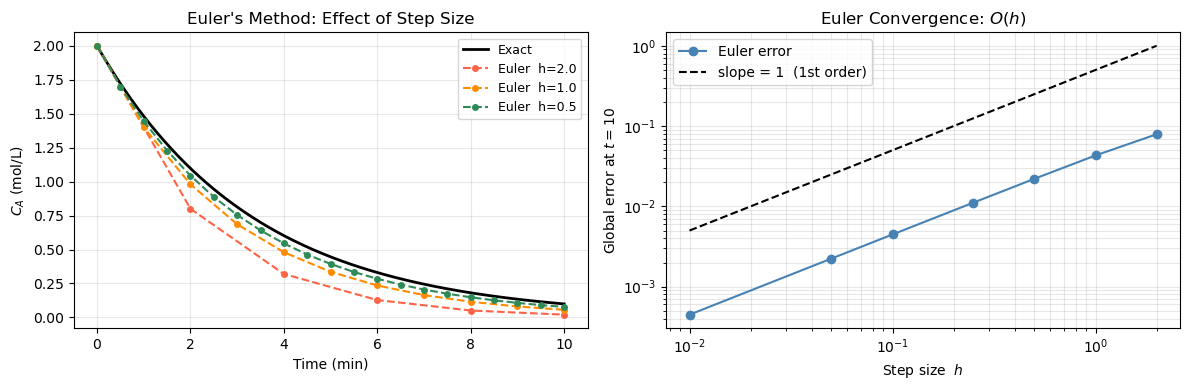

In [4]:
# ── Euler's method for dC_A/dt = -k*C_A ─────────────────────────────────────

def dCA_dt(t, C_A):
    return -k * C_A          # f(t, y)  — the ODE right-hand side

def euler(f, y0, t_span, h):
    """Simple Euler integrator.  Returns (t_array, y_array)."""
    t0, tf = t_span
    t_arr = [t0]
    y_arr = [y0]
    t_cur, y_cur = t0, y0
    while t_cur < tf - 1e-10:
        h_step = min(h, tf - t_cur)   # don't overshoot the end
        y_cur  = y_cur + h_step * f(t_cur, y_cur)
        t_cur  = t_cur + h_step
        t_arr.append(t_cur)
        y_arr.append(y_cur)
    return np.array(t_arr), np.array(y_arr)

# Compare three step sizes
t_exact = np.linspace(0, 10, 400)
C_exact = C_A0 * np.exp(-k * t_exact)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(t_exact, C_exact, 'k-', linewidth=2, label='Exact')
colors = ['tomato', 'darkorange', 'seagreen']
for h_val, color in zip([2.0, 1.0, 0.5], colors):
    t_eu, y_eu = euler(dCA_dt, C_A0, (0, 10), h_val)
    ax.plot(t_eu, y_eu, 'o--', color=color, markersize=4,
            label=f'Euler  h={h_val}')
ax.set_xlabel('Time (min)')
ax.set_ylabel('$C_A$ (mol/L)')
ax.set_title("Euler's Method: Effect of Step Size")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Error vs step size
ax2 = axes[1]
h_vals = [2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.01]
errors = []
for h_val in h_vals:
    _, y_eu = euler(dCA_dt, C_A0, (0, 10), h_val)
    C_ref = C_A0 * np.exp(-k * 10)
    errors.append(abs(y_eu[-1] - C_ref))

ax2.loglog(h_vals, errors, 'o-', color='steelblue', markersize=6, label='Euler error')
# Reference slope-1 line
h_ref = np.array([0.01, 2.0])
ax2.loglog(h_ref, 0.5 * h_ref, 'k--', label='slope = 1  (1st order)')
ax2.set_xlabel('Step size  $h$')
ax2.set_ylabel('Global error at $t=10$')
ax2.set_title('Euler Convergence: $O(h)$')
ax2.legend(fontsize=10)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

(18.3)=
## 18.3 Solving ODEs in Python with `solve_ivp`

In 18.2 we stepped through Euler's method by hand. In practice we hand the ODE to `scipy.integrate.solve_ivp`, which does the same march-forward idea but with a smarter algorithm under the hood. This section shows the full workflow in three steps:

1. **Write** the ODE as a Python function
2. **Call** `solve_ivp` and read the result
3. **Understand** what the solver is doing internally

### 18.3.1 Step 1 — Write the ODE as a Python function

`solve_ivp` expects the right-hand side $f(t, y)$ as a function with this exact signature:

```python
def rhs(t, y):
    # t      : current time (scalar)
    # y      : current state — always a list/array, one entry per variable
    # return : list of derivatives, same length as y
    return [dy_dt]
```

**Two rules that trip up most beginners:**
- `y` is **always a list**, even for a single variable — unpack it with `y[0]`
- Always **return a list** (never a bare scalar)


In [2]:
# ── Step 1: writing ODE functions ────────────────────────────────────────────

# Example A: single variable
#   dy/dt = k*y   →   y = [C_A],  y[0] = C_A
#   dC_A / dt = k C_A


k = 0.3

def rhs_single(t, y):
    C_A = y[0]
    return [k*C_A]


print("Example A — RHS at t=0, C_A=1.0:", rhs_single(0, [1.0]))
# Expected: [0.3]

Example A — RHS at t=0, C_A=1.0: [0.3]


In [4]:
# Example B: two coupled variables
#   dC_A/dt = -k1 * C_A
#   dC_B/dt =  k1 * C_A - k2 * C_B
#   y = [C_A, C_B]

k1, k2 = 0.4, 0.1

def rhs_system(t, y):
    C_A = y[0]
    C_B = y[1]
    return [-k1*C_A,
            k1*C_A - k2*C_B]


print("Example B — RHS at t=0, [C_A, C_B]=[1, 0]:", rhs_system(0, [1.0, 0.0]))
# Expected: [-0.4, 0.4]


Example B — RHS at t=0, [C_A, C_B]=[1, 0]: [-0.4, 0.4]


### 18.3.2 Step 2 — Call `solve_ivp` and read the result

```python
from scipy.integrate import solve_ivp

sol = solve_ivp(fun, t_span, y0, t_eval=..., args=(...))
```

| Argument | What to pass | Notes |
|----------|-------------|-------|
| `fun` | your `rhs(t, y)` function | must accept scalar `t`, list `y` |
| `t_span` | `(t_start, t_end)` | integration interval |
| `y0` | `[y_initial, ...]` | one value per ODE variable |
| `t_eval` | `np.linspace(t0, tf, N)` | times where output is saved |
| `args` | `(k,)` or `(k1, k2)` | extra parameters forwarded to `fun` |

The returned object `sol` contains:

| Attribute | Shape | Meaning |
|-----------|-------|---------|
| `sol.t` | `(N,)` | time points |
| `sol.y` | `(n_vars, N)` | solution — **row `i` = variable `i`** |
| `sol.success` | bool | `True` if the solver converged |

```python
sol.y[0]      # first variable over all time points
sol.y[0, -1]  # final value of first variable
sol.y[1]      # second variable (if system)
```


In [22]:
# ── Step 2: calling solve_ivp and reading the result ─────────────────────────
from scipy.integrate import solve_ivp

# ODE:  dC_A/dt = k * C_A,   C_A(0) = 0.5

k = 0.3

def rhs(t, y):
    C_A = y[0]
    return [k*C_A]

sol = solve_ivp(fun   = rhs, 
               t_span = (0, 10),
               y0     = [0.5],
               t_eval = np.linspace(0, 10, 6))
sol



  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  2.000e+00  4.000e+00  6.000e+00  8.000e+00
             1.000e+01]
        y: [[ 5.000e-01  9.111e-01  1.660e+00  3.025e+00  5.510e+00
              1.004e+01]]
      sol: None
 t_events: None
 y_events: None
     nfev: 32
     njev: 0
      nlu: 0

In [23]:
print("Converged :", sol.success)
print("Time pts  :", sol.t)
print("C_A values:", sol.y[0])

Converged : True
Time pts  : [ 0.  2.  4.  6.  8. 10.]
C_A values: [ 0.5         0.91111541  1.65990392  3.02519513  5.50988003 10.04272124]


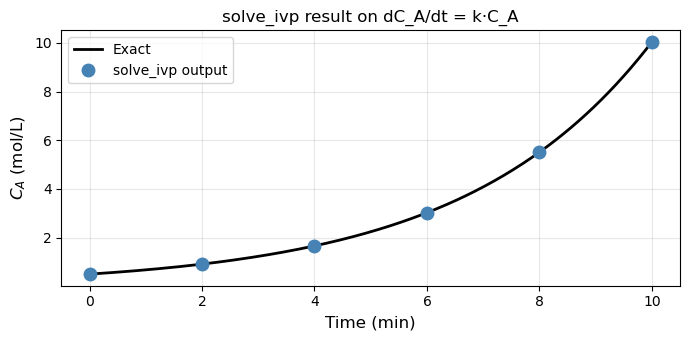

In [24]:
# Quick plot

t_fine = np.linspace(0, 10, 300)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(t_fine, 0.5 * np.exp(k * t_fine), 'k-', lw=2, label='Exact')
ax.plot(sol.t, sol.y[0], 'o', color='steelblue', ms=9, zorder=5,
        label='solve_ivp output')
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('$C_A$ (mol/L)', fontsize=12)
ax.set_title('solve_ivp result on dC_A/dt = k·C_A', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 18.3.3 (Optional) Step 3 — What is `solve_ivp` doing under the hood?

The default method `'RK45'` works exactly like Euler — it marches forward from $y_0$ — but instead of one slope evaluation per step it takes **four**, placed at the start, two midpoints, and the end of the interval, then combines them with optimal weights:

$$
y_{n+1} = y_n + \frac{h}{6}\bigl(k_1 + 2k_2 + 2k_3 + k_4\bigr)
$$

where each $k_i$ is a slope evaluated at a different point within the step. This weighted average tracks the curve far better than Euler's single slope.

**Why RK45 instead of plain RK4?** The "45" means it computes *two* estimates (4th-order and 5th-order) at every step. Their difference is used as an error gauge: if the error is too large, the step is **rejected and retried** with smaller $h$; if the error is tiny, the next step uses larger $h$. You never have to choose $h$ — the solver adapts it automatically.

| Method | Error order | Halving $h$ reduces error by | Step size |
|--------|------------|------------------------------|-----------|
| Euler | $O(h)$ | 2× | fixed |
| RK4 | $O(h^4)$ | 16× | fixed |
| **RK45** | **adaptive** | **controlled by `rtol`/`atol`** | **automatic** |

**`rtol` and `atol`** are the two tolerances that tell the solver how accurate to be:
- `rtol=1e-3` (default) — relative tolerance: error / |y| ≤ 0.001 at each step
- `atol=1e-6` (default) — absolute tolerance: guards against issues when y ≈ 0

For most ChE problems the defaults are fine. Tighten to `rtol=1e-6, atol=1e-9` when you need high-fidelity results (e.g. stiff reactors, phase portraits).


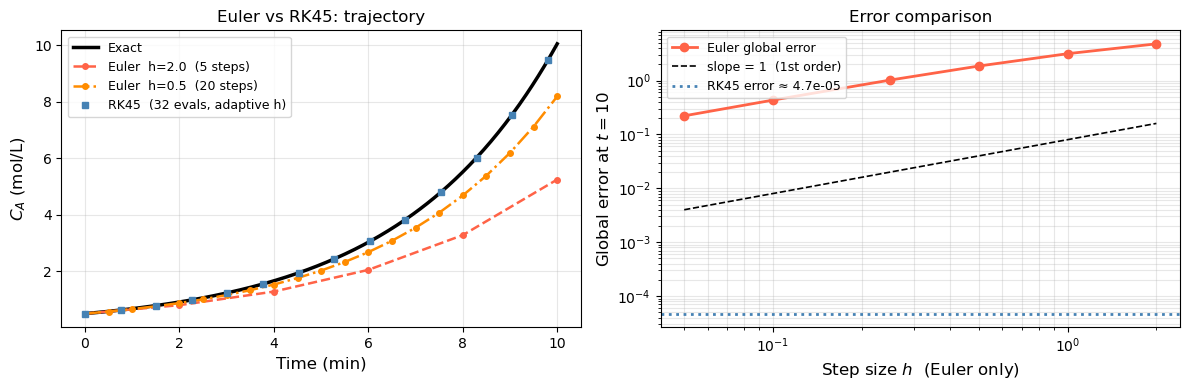

Euler h=2.0  error: 4.7999
Euler h=0.5  error: 1.8595
RK45         error: 4.72e-05  (with 32 function evaluations)


In [25]:
# ── Step 3: Euler vs solve_ivp — same ODE, same number of points ─────────────

k   = 0.3
y0_ = 0.5

def rhs_grow(t, y): return [k * y[0]]

def euler_solve(h, t_end=10):
    ts, ys = [0.0], [y0_]
    while ts[-1] < t_end - 1e-10:
        hh = min(h, t_end - ts[-1])
        ys.append(ys[-1] + hh * k * ys[-1])
        ts.append(ts[-1] + hh)
    return np.array(ts), np.array(ys)

t_fine = np.linspace(0, 10, 400)
y_exact = y0_ * np.exp(k * t_fine)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: trajectory comparison
ax = axes[0]
ax.plot(t_fine, y_exact, 'k-', lw=2.5, label='Exact')
for h_val, color, ls in [(2.0, 'tomato', '--'), (0.5, 'darkorange', '-.')]:
    te, ye = euler_solve(h_val)
    ax.plot(te, ye, color=color, ls=ls, lw=1.8, marker='o', ms=4,
            label=f'Euler  h={h_val}  ({len(te)-1} steps)')
sol_rk = solve_ivp(rhs_grow, (0, 10), [y0_], t_eval=np.linspace(0, 10, 200))
ax.plot(sol_rk.t, sol_rk.y[0], 's', color='steelblue', ms=4, markevery=15,
        label=f'RK45  ({sol_rk.nfev} evals, adaptive h)')
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('$C_A$ (mol/L)', fontsize=12)
ax.set_title('Euler vs RK45: trajectory', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: error vs step size
ax2 = axes[1]
h_vals = np.array([2.0, 1.0, 0.5, 0.25, 0.1, 0.05])
y_ref  = y0_ * np.exp(k * 10)
euler_errs = [abs(euler_solve(hv)[1][-1] - y_ref) for hv in h_vals]

ax2.loglog(h_vals, euler_errs, 'o-', color='tomato', lw=2, label='Euler global error')
h_ref = np.array([h_vals[-1], h_vals[0]])
ax2.loglog(h_ref, 0.08 * h_ref, 'k--', lw=1.2, label='slope = 1  (1st order)')

rk_err = abs(sol_rk.y[0, -1] - y_ref)
ax2.axhline(rk_err, color='steelblue', lw=2, ls=':', label=f'RK45 error ≈ {rk_err:.1e}')

ax2.set_xlabel('Step size $h$  (Euler only)', fontsize=12)
ax2.set_ylabel('Global error at $t=10$', fontsize=12)
ax2.set_title('Error comparison', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Euler h=2.0  error: {abs(euler_solve(2.0)[1][-1] - y_ref):.4f}")
print(f"Euler h=0.5  error: {abs(euler_solve(0.5)[1][-1] - y_ref):.4f}")
print(f"RK45         error: {rk_err:.2e}  (with {sol_rk.nfev} function evaluations)")


### 18.3.4 Passing Parameters with `args`

When your ODE contains physical parameters (rate constants, temperatures, …), pass them via the `args` keyword instead of using global variables:

```python
def rhs(t, y, k):       # k is an extra argument
    return [k * y[0]]

sol = solve_ivp(rhs, (0, 10), [0.5], args=(0.3,))
#                                          ^^^^^ tuple — note the trailing comma!
```

> **Common mistake:** `args=(k)` is just parentheses around `k`, not a tuple. Write `args=(k,)` with a trailing comma.

This makes the function reusable — you can loop over parameter values without redefining `rhs` each time.


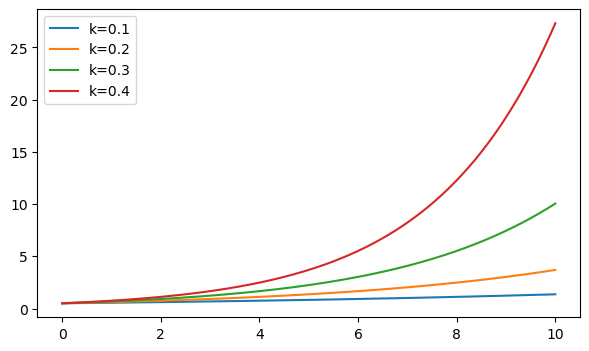

In [31]:
# ── 18.3.4  args: parameter sweep without redefining the function ─────────────

#   dy/dt = k*y   →   y = [C_A],  y[0] = C_A
# k = 0.3

# def rhs_single(t, y):
#     C_A = y[0]          # unpack
#     return [k * C_A]    # return a list


def rhs_params(t, y, k):
    return [k * y[0]]


# t_eval = np.linspace(0, 10, 300)

fig, ax = plt.subplots(figsize=(7,4))

for k_val in [0.1, 0.2, 0.3, 0.4]:
    sol = solve_ivp(rhs_params, (0, 10), [0.5], t_eval = np.linspace(0, 10, 300), args=(k_val, ))
    ax.plot(sol.t, sol.y[0], label=f'k={k_val}')

plt.legend()


In [ ]:
t_eval = np.linspace(0, 10, 300)

fig, ax = plt.subplots(figsize=(7, 4))
for k_val, color in zip([0.1, 0.2, 0.3, 0.5], ['steelblue', 'seagreen', 'darkorange', 'tomato']):
    sol = solve_ivp(rhs_param, (0, 10), [0.5], args=(k_val,), t_eval=t_eval)
    ax.plot(sol.t, sol.y[0], color=color, lw=2, label=f'k = {k_val} min\u207b\xb9')

ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('$C_A$ (mol/L)', fontsize=12)
ax.set_title('Parameter sweep using args=(k,)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(18.4)=
## 18.4 Systems of ODEs

A **system of ODEs** is a set of two or more differential equations that are **coupled** — the rate of change of each variable depends on the current values of the other variables. Instead of tracking one unknown function $y(t)$, we track a **vector** of unknowns $\mathbf{y}(t) = [y_1, y_2, \ldots, y_n]$, each with its own equation:

$$
\frac{dy_1}{dt} = f_1(t,\, y_1, y_2, \ldots, y_n)
$$
$$
\frac{dy_2}{dt} = f_2(t,\, y_1, y_2, \ldots, y_n)
$$
$$
\vdots
$$
$$
\frac{dy_n}{dt} = f_n(t,\, y_1, y_2, \ldots, y_n)
$$

In Python, `y` is a list/array and your `rhs` function returns a list of the same length — one derivative per variable.

**Two common sources of systems in ChE:**
1. **Multiple species** — material balances on $n$ components each give one ODE, coupled through reaction rates.
2. **Higher-order ODEs** — a single $n$th-order ODE is rewritten as $n$ first-order ODEs by introducing new state variables for each derivative.

`solve_ivp` handles systems exactly like single ODEs: pass the full `y0` vector and the `rhs` function that returns a vector of the same length.

### 18.4.1 Consecutive Reactions: A → B → C

A classic ChE scenario: reactant A converts to intermediate B, which then converts to product C.

$$
A \xrightarrow{k_1} B \xrightarrow{k_2} C
$$

**Material balances** (liquid phase, constant volume):

$$
\frac{dC_A}{dt} = -k_1 C_A
$$
$$
\frac{dC_B}{dt} = k_1 C_A - k_2 C_B
$$
$$
\frac{dC_C}{dt} = k_2 C_B
$$

Three equations, three unknowns. `y = [C_A, C_B, C_C]`.

Note that $C_A + C_B + C_C = \text{const}$ (total moles conserved) — a good check for correctness.

In [33]:
# ── Consecutive reactions A → B → C ──────────────────────────────────────────

k1 = 0.4    # 1/min  (A → B)
k2 = 0.1    # 1/min  (B → C)


def cons_rxn(t, y, k1, k2):
    C_A, C_B, C_C = y
    dCA = -k1*C_A
    dCB = k1*C_A - k2*C_B
    dCC = k2*C_B
    return [dCA, dCB, dCC]

sol = solve_ivp(cons_rxn, t_span = (0, 20), y0=[1.0, 0.0, 0.0], args=(k1, k2))



In [ ]:
# Check mass conservation

Maximum C_B = 0.6291 mol/L  at  t = 4.87 min


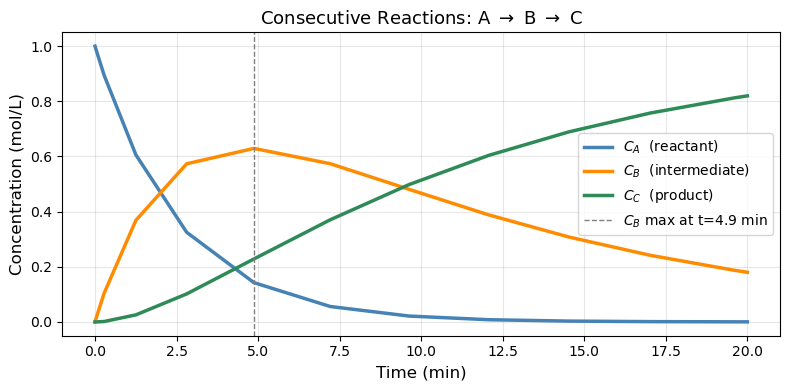

In [34]:
# Find time of maximum C_B
idx_max = np.argmax(sol.y[1])
t_max_B = sol.t[idx_max]
print(f"Maximum C_B = {sol.y[1, idx_max]:.4f} mol/L  at  t = {t_max_B:.2f} min")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sol.t, sol.y[0], 'steelblue',  linewidth=2.5, label='$C_A$  (reactant)')
ax.plot(sol.t, sol.y[1], 'darkorange', linewidth=2.5, label='$C_B$  (intermediate)')
ax.plot(sol.t, sol.y[2], 'seagreen',   linewidth=2.5, label='$C_C$  (product)')
ax.axvline(t_max_B, color='gray', linestyle='--', linewidth=1,
           label=f'$C_B$ max at t={t_max_B:.1f} min')
ax.set_xlabel('Time (min)', fontsize=12)
ax.set_ylabel('Concentration (mol/L)', fontsize=12)
ax.set_title(r'Consecutive Reactions: A $\rightarrow$ B $\rightarrow$ C', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 18.4.2 Second-Order ODE: Controlled Tank Level

**The situation:** A liquid tank has an inlet controlled by a valve, and the goal is to hold the tank level $h$ at a desired setpoint $h_{ss}$. A sensor measures the current level and sends an error signal to the valve: if $h$ is too low, open the valve more; if too high, close it. This feedback loop is the controller.

The valve, however, has mechanical inertia — a physical plug with mass and a spring that resists sudden motion. Because of this inertia, the valve doesn't respond instantly to the error signal: it accelerates, then decelerates as it approaches the commanded position. This lag couples the valve's velocity into the level dynamics, introducing a **second derivative** and giving the system **second-order behavior**.

---

**Deriving the ODE — step by step**

**Step 1: Tank material balance.**  
The rate of change of liquid volume equals flow in minus flow out. Dividing by the cross-sectional area $A_t$:

$$
A_t \frac{dh}{dt} = F_{in}(t) - F_{out}
$$

We treat $F_{out}$ as constant (fixed downstream resistance), so only $F_{in}$ varies.

**Step 2: Valve force balance.**  
The valve has a physical plug with mass $m_v$ attached to a spring ($k_s$) and subject to friction ($b$). When the controller sees a level error $(h_{ss} - h)$, it pushes the plug with force $K_c(h_{ss} - h)$. Newton's second law on the plug:

$$
m_v \ddot{x} + b\dot{x} + k_s x = K_c(h_{ss} - h)
$$

where $x$ is the plug displacement from its neutral position.

**Step 3: Link valve position to flow.**  
Flow through the valve is proportional to how far the plug is open:

$$
F_{in} = \alpha\, x \quad\Longrightarrow\quad x = \frac{F_{in}}{\alpha}
$$

Substitute into the force balance (replacing $x$ with $F_{in}/\alpha$ and absorbing $\alpha$ into a new gain $\tilde K$):

$$
\frac{m_v}{k_s}\ddot{F}_{in} + \frac{b}{k_s}\dot{F}_{in} + F_{in} = \tilde{K}(h_{ss} - h)
$$

**Step 4: Substitute the material balance.**  
From Step 1, $F_{in} = A_t \frac{dh}{dt} + F_{out}$. Since $F_{out}$ is constant, $\dot{F}_{in} = A_t \ddot{h}$ and $\ddot{F}_{in} = A_t \dddot{h}$... but that gives a third-order equation. Instead, we close the loop at steady state: at steady state $h = h_{ss}$, $\dot h = 0$, so $F_{in} = F_{out}$. Writing the deviation from steady state and combining the tank and valve equations into one expression in $h$ only yields:

$$
\frac{m_v}{k_s} \frac{d^2h}{dt^2} + \frac{b}{k_s} \frac{dh}{dt} + h = h_{ss}
$$

**Step 5: Define standard parameters.**  
Group the physical constants into two dimensionless/dimensional quantities:

$$
\tau = \sqrt{\frac{m_v}{k_s}} \qquad \zeta = \frac{b}{2\sqrt{m_v k_s}}
$$

Then $\frac{m_v}{k_s} = \tau^2$ and $\frac{b}{k_s} = \frac{2\zeta\tau^2}{\tau} \cdot \frac{1}{1} = 2\zeta\tau$. The ODE becomes the standard **second-order closed-loop form**:

$$
\boxed{\tau^2 \frac{d^2h}{dt^2} + 2\zeta\tau\frac{dh}{dt} + h = h_{ss}}
$$

| Parameter | Formula | Physical meaning |
|-----------|---------|-----------------|
| $\tau = \sqrt{m_v/k_s}$ | time constant (min) | How fast the valve naturally oscillates |
| $\zeta = b/(2\sqrt{m_v k_s})$ | damping ratio (–) | How much friction damps the valve motion |

---

**What $\zeta$ controls:**

| $\zeta$ | Valve character | Level response |
|---------|----------------|----------------|
| $\zeta < 1$ | Lightly damped (slippery valve) | Overshoots $h_{ss}$, oscillates before settling |
| $\zeta = 1$ | Critically damped | Reaches $h_{ss}$ as fast as possible, no overshoot |
| $\zeta > 1$ | Heavily damped (sluggish valve) | Creeps slowly to $h_{ss}$, no overshoot |

---

The simulation below shows a **step change**: the tank starts empty ($h = 0$, valve at rest) and the setpoint jumps to $h_{ss} = 1$ m at $t = 0$.

**Rewrite as a first-order system** for `solve_ivp` by letting $y_1 = h$ and $y_2 = \frac{dh}{dt}$:

$$
\frac{dy_1}{dt} = y_2
\qquad
\frac{dy_2}{dt} = \frac{1}{\tau^2}\left(h_{ss} - y_1 - 2\zeta\tau\, y_2\right)
$$


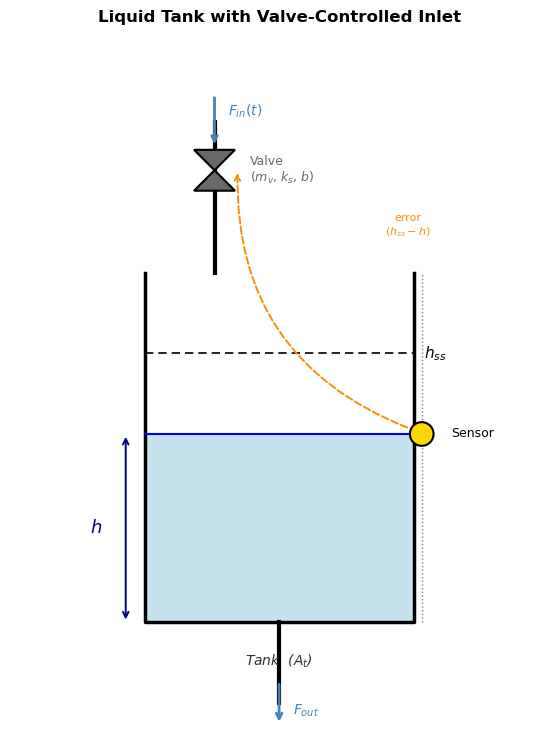

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(6, 7.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.set_aspect('equal')
ax.axis('off')

# ── Tank walls (three sides, open top) ───────────────────────────────────────
tank_l, tank_r = 2.5, 7.5
tank_bot, tank_top = 2.0, 8.5

ax.plot([tank_l, tank_l, tank_r, tank_r],
        [tank_top, tank_bot, tank_bot, tank_top],
        'k-', linewidth=2.5)

# ── Liquid fill ───────────────────────────────────────────────────────────────
liquid_h = 5.5
ax.add_patch(mpatches.Rectangle(
    (tank_l, tank_bot), tank_r - tank_l, liquid_h - tank_bot,
    facecolor='#add8e6', edgecolor='none', alpha=0.7, zorder=1))
ax.plot([tank_l, tank_r], [liquid_h, liquid_h], 'b-', linewidth=1.5)

# ── h arrow and label ─────────────────────────────────────────────────────────
ax.annotate('', xy=(tank_l - 0.35, liquid_h), xytext=(tank_l - 0.35, tank_bot),
            arrowprops=dict(arrowstyle='<->', color='navy', lw=1.4))
ax.text(tank_l - 0.9, (liquid_h + tank_bot) / 2, '$h$',
        ha='center', va='center', fontsize=13, color='navy')

# ── Setpoint dashed line ──────────────────────────────────────────────────────
ax.plot([tank_l, tank_r], [7.0, 7.0], 'k--', linewidth=1.2, dashes=(5, 3))
ax.text(tank_r + 0.2, 7.0, '$h_{ss}$', va='center', fontsize=11)

# ── Inlet pipe (vertical, enters from top) ────────────────────────────────────
pipe_x = 3.8
ax.plot([pipe_x, pipe_x], [tank_top, 11.3], 'k-', linewidth=3)

# ── Valve symbol (bowtie) ─────────────────────────────────────────────────────
vx, vy, vs = pipe_x, 10.4, 0.38
ax.add_patch(plt.Polygon(
    [[vx - vs, vy + vs], [vx + vs, vy + vs], [vx, vy]],
    closed=True, facecolor='dimgray', edgecolor='k', linewidth=1.5, zorder=4))
ax.add_patch(plt.Polygon(
    [[vx - vs, vy - vs], [vx + vs, vy - vs], [vx, vy]],
    closed=True, facecolor='dimgray', edgecolor='k', linewidth=1.5, zorder=4))
ax.text(vx + 0.65, vy, 'Valve\n($m_v$, $k_s$, $b$)',
        va='center', fontsize=9, color='dimgray')

# Flow arrow above valve
ax.annotate('', xy=(pipe_x, vy + vs + 0.05), xytext=(pipe_x, 11.8),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.text(pipe_x + 0.25, 11.65, '$F_{in}(t)$', fontsize=10, va='top', color='steelblue')

# ── Outlet pipe (bottom center) ───────────────────────────────────────────────
out_x = 5.0
ax.plot([out_x, out_x], [tank_bot, 0.5], 'k-', linewidth=3)
ax.annotate('', xy=(out_x, 0.1), xytext=(out_x, 0.9),
            arrowprops=dict(arrowstyle='->', color='steelblue', lw=2))
ax.text(out_x + 0.25, 0.35, '$F_{out}$', fontsize=10, va='center', color='steelblue')

# ── Level sensor (circle on tank wall) ───────────────────────────────────────
sx = tank_r + 0.15
ax.plot([sx, sx], [tank_bot, tank_top], color='gray', linewidth=1, linestyle=':')
ax.add_patch(mpatches.Circle((sx, liquid_h), 0.22,
             facecolor='gold', edgecolor='k', linewidth=1.5, zorder=5))
ax.text(sx + 0.55, liquid_h, 'Sensor', fontsize=9, va='center')

# ── Error signal arrow (sensor → valve) ──────────────────────────────────────
ax.annotate('', xy=(vx + vs + 0.05, vy),
            xytext=(sx - 0.22, liquid_h + 0.1),
            arrowprops=dict(arrowstyle='->', color='darkorange', lw=1.4,
                            linestyle='dashed',
                            connectionstyle='arc3,rad=-0.35'))
ax.text(7.4, 9.2, 'error\n$(h_{ss}-h)$',
        fontsize=8, color='darkorange', ha='center')

# ── Tank label ────────────────────────────────────────────────────────────────
ax.text(5.0, 1.2, 'Tank  ($A_t$)', ha='center', fontsize=10,
        style='italic', color='#333')

ax.set_title('Liquid Tank with Valve-Controlled Inlet', fontsize=12,
             fontweight='bold', pad=6)
plt.tight_layout()
plt.show()


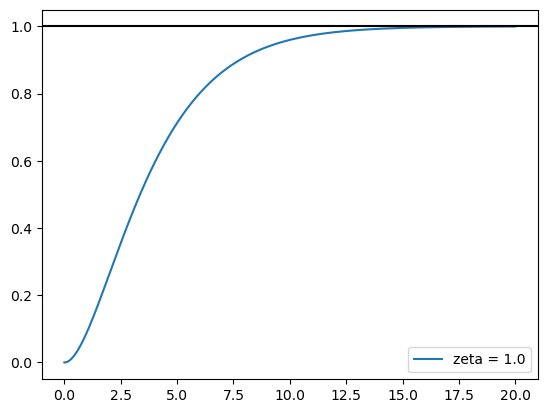

In [19]:
# ── Second-order ODE: damped oscillator ──────────────────────────────────────
# ζ = 0.3 (underdamped case)
# ζ = 1.0 (critically damped case)
# ζ = 2.0 (overdamped case)


tau = 2.0      # time constant (min)
h_ss = 1.0     # steady-state level (m) — step change from h=0
t_eval = np.linspace(0, 20, 400)
y0 = [0.0, 0.0]   # starts at rest at h=0

def damped_oscillator(t, y, tau, zeta, h_ss):
    h, dhdt = y # y1 y2
    d2hdt = (h_ss - h - 2*zeta*tau*dhdt) / tau**2
    return [dhdt, d2hdt]

zeta = 1.0
sol = solve_ivp(damped_oscillator, (0, 20), y0, args=(tau, zeta, h_ss), t_eval=t_eval)

plt.plot(sol.t, sol.y[0], label=f'zeta = {zeta}')
plt.axhline(1, color='k')
plt.legend()

(18.5)=
## 18.5 (Optional) Stiff ODEs

### 18.5.1 What is Stiffness?

A system is **stiff** when it contains processes operating on vastly different time scales simultaneously. For example, in chemical kinetics:

$$
\frac{dC_A}{dt} = -10^6\, C_A + C_B
\qquad
\frac{dC_B}{dt} = 10^{-3}\, C_A
$$

The first equation has a "fast" term ($k_1 = 10^6$) and a "slow" term. To remain stable, an explicit method like RK45 must take tiny steps sized to the *fastest* time scale — even when the solution is actually changing slowly. This makes RK45 extremely slow (millions of steps) on stiff problems.

**Rule of thumb:** if RK45 takes a very long time or requires very small steps with no apparent reason, try `method='Radau'` or `method='BDF'`.

### 18.5.2 Stiff Solvers

| Method | Type | Best for |
|--------|------|----------|
| `'RK45'` | Explicit, adaptive | Smooth, non-stiff problems |
| `'RK23'` | Explicit, lower order | Quick/rough solutions |
| `'Radau'` | Implicit Runge-Kutta | **Stiff problems** |
| `'BDF'` | Implicit multi-step | **Stiff problems**, large systems |
| `'LSODA'` | Auto-switching | When stiffness is uncertain |

**Implicit methods** solve a system of equations at each step — more work per step, but can take huge steps, so they win on stiff problems.

### 18.5.3 Example: Fast and Slow Reaction Network

Consider a reaction network where species $X$ is produced and consumed very rapidly (a "short-lived intermediate"):

$$
A \xrightarrow{k_1 = 1000} X, \quad X \xrightarrow{k_2 = 1000} B, \quad A \xrightarrow{k_3 = 0.01} B
$$

RK45 :   2246 function evaluations,  13.2 ms
Radau:    345 function evaluations,  5.3 ms


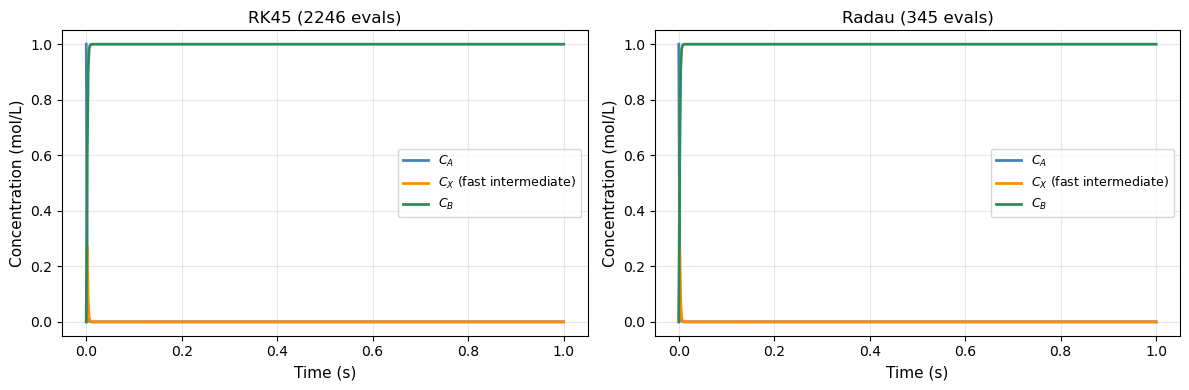

In [11]:
# ── Stiff system: compare RK45 vs Radau ──────────────────────────────────────
import time

k1_s, k2_s, k3_s = 1000.0, 1000.0, 0.01

def stiff_rxn(t, y):
    C_A, C_X, C_B = y
    dCA = -k1_s * C_A - k3_s * C_A
    dCX =  k1_s * C_A - k2_s * C_X
    dCB =  k2_s * C_X + k3_s * C_A
    return [dCA, dCX, dCB]

y0_stiff = [1.0, 0.0, 0.0]
t_span   = (0, 1.0)
t_eval   = np.linspace(0, 1.0, 500)

# RK45
t0 = time.time()
sol_rk45 = solve_ivp(stiff_rxn, t_span, y0_stiff,
                     method='RK45', t_eval=t_eval, rtol=1e-4, atol=1e-7)
t_rk45 = time.time() - t0

# Radau
t0 = time.time()
sol_radau = solve_ivp(stiff_rxn, t_span, y0_stiff,
                      method='Radau', t_eval=t_eval, rtol=1e-4, atol=1e-7)
t_radau = time.time() - t0

print(f"RK45 :  {sol_rk45.nfev:5d} function evaluations,  {t_rk45*1000:.1f} ms")
print(f"Radau:  {sol_radau.nfev:5d} function evaluations,  {t_radau*1000:.1f} ms")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, sol, title in zip(axes, [sol_rk45, sol_radau], ['RK45', 'Radau']):
    ax.plot(sol.t, sol.y[0], 'steelblue',  linewidth=2, label='$C_A$')
    ax.plot(sol.t, sol.y[1], 'darkorange', linewidth=2, label='$C_X$ (fast intermediate)')
    ax.plot(sol.t, sol.y[2], 'seagreen',   linewidth=2, label='$C_B$')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel('Concentration (mol/L)', fontsize=11)
    ax.set_title(f'{title} ({sol.nfev} evals)', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

(18.6)=
## 18.6 ChE Application: Non-Isothermal Batch Reactor

The most important ODE application in ChE is the **non-isothermal reactor** — where both concentration and temperature evolve together. The temperature affects the rate (Arrhenius), and the reaction releases heat which changes the temperature. These two effects are **coupled**.

### 18.6.1 Model Equations

Consider an **exothermic first-order liquid-phase reaction** $A \to B$ in an adiabatic batch reactor:

**Mole balance:**
$$
\frac{dC_A}{dt} = -k(T)\, C_A
$$

**Energy balance** (adiabatic, liquid phase):
$$
\rho C_p \frac{dT}{dt} = (-\Delta H_{rxn})\, k(T)\, C_A
$$

**Arrhenius rate:**
$$
k(T) = A\, e^{-E_a / RT}
$$

The two equations are **coupled**: temperature changes $k$, which changes the rate of $C_A$ consumption, which changes the heat released.

### 18.6.2 Physical Parameters

We use parameters typical of an industrial hydrogenation:

| Parameter | Value | Units |
|-----------|-------|-------|
| Pre-exponential $A$ | $1.0 \times 10^{10}$ | min⁻¹ |
| Activation energy $E_a$ | $75{,}000$ | J/mol |
| $-\Delta H_{rxn}$ | $50{,}000$ | J/mol |
| $\rho C_p$ | $4{,}000$ | J/(L·K) |
| $C_{A0}$ | $2.0$ | mol/L |
| $T_0$ | $300$ | K |

Final conversion X_A = 0.0267
Final temperature  T = 300.67 K  (ΔT = 0.67 K)
Adiabatic temp rise (check): 25.00 K


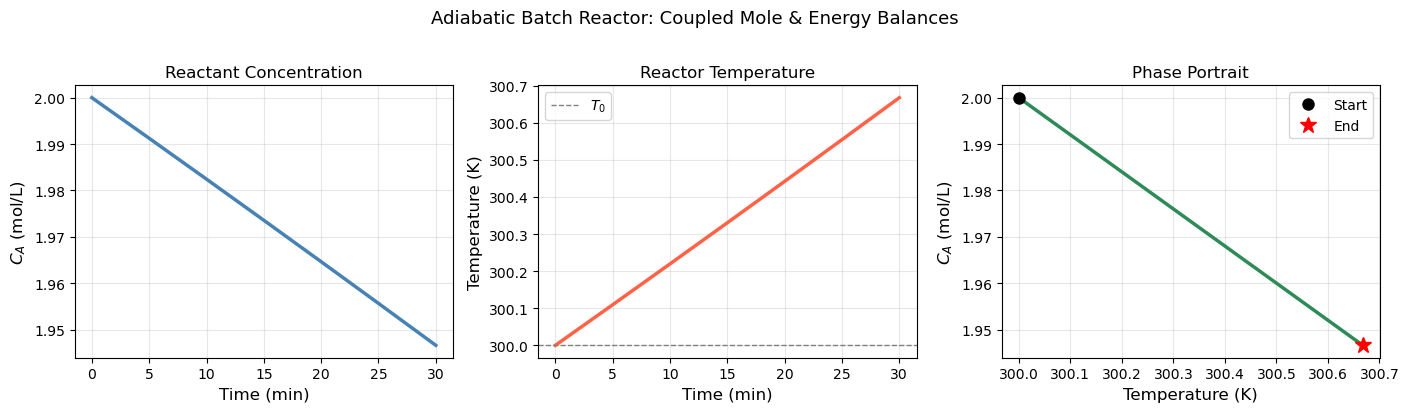

In [12]:
# ── Non-isothermal adiabatic batch reactor ───────────────────────────────────

R_gas  = 8.314       # J/(mol·K)
A_arr  = 1.0e10      # pre-exponential  (1/min)
Ea     = 75_000.0    # activation energy (J/mol)
dH_rxn = -50_000.0   # heat of reaction  (J/mol)  — exothermic → negative
rho_Cp = 4_000.0     # volumetric heat capacity (J/(L·K))

C_A0_batch = 2.0     # mol/L
T0_batch   = 300.0   # K

def batch_reactor(t, y):
    C_A, T = y
    k_T    = A_arr * np.exp(-Ea / (R_gas * T))
    dCA_dt = -k_T * C_A
    dT_dt  = (-dH_rxn) * k_T * C_A / rho_Cp
    return [dCA_dt, dT_dt]

t_eval = np.linspace(0, 30, 600)
sol_batch = solve_ivp(batch_reactor,
                      t_span=(0, 30),
                      y0=[C_A0_batch, T0_batch],
                      method='Radau',          # can be stiff near ignition
                      t_eval=t_eval,
                      rtol=1e-7, atol=1e-9)

C_A_sol = sol_batch.y[0]
T_sol   = sol_batch.y[1]

# Conversion
X_A = (C_A0_batch - C_A_sol) / C_A0_batch

print(f"Final conversion X_A = {X_A[-1]:.4f}")
print(f"Final temperature  T = {T_sol[-1]:.2f} K  (ΔT = {T_sol[-1]-T0_batch:.2f} K)")
print(f"Adiabatic temp rise (check): {-dH_rxn * C_A0_batch / rho_Cp:.2f} K")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Concentration
axes[0].plot(sol_batch.t, C_A_sol, 'steelblue', linewidth=2.5)
axes[0].set_xlabel('Time (min)', fontsize=12)
axes[0].set_ylabel('$C_A$ (mol/L)', fontsize=12)
axes[0].set_title('Reactant Concentration', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Temperature
axes[1].plot(sol_batch.t, T_sol, 'tomato', linewidth=2.5)
axes[1].axhline(T0_batch, color='gray', linestyle='--', linewidth=1, label='$T_0$')
axes[1].set_xlabel('Time (min)', fontsize=12)
axes[1].set_ylabel('Temperature (K)', fontsize=12)
axes[1].set_title('Reactor Temperature', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Phase plot: C_A vs T
axes[2].plot(T_sol, C_A_sol, 'seagreen', linewidth=2.5)
axes[2].plot(T0_batch, C_A0_batch, 'ko', markersize=8, label='Start')
axes[2].plot(T_sol[-1], C_A_sol[-1], 'r*', markersize=12, label='End')
axes[2].set_xlabel('Temperature (K)', fontsize=12)
axes[2].set_ylabel('$C_A$ (mol/L)', fontsize=12)
axes[2].set_title('Phase Portrait', fontsize=12)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Adiabatic Batch Reactor: Coupled Mole & Energy Balances', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 18.6.3 CSTR Start-Up Dynamics

A **continuous stirred tank reactor (CSTR)** at start-up must transition from empty (initial conditions) to steady state. The governing equations are:

**Mole balance** (liquid phase, constant volume $V$, volumetric flow rate $Q$):
$$
\frac{dC_A}{dt} = \frac{Q}{V}(C_{A,\text{in}} - C_A) - k(T)\, C_A
$$

**Energy balance** (with jacket cooling at temperature $T_c$):
$$
\rho C_p \frac{dT}{dt} = \frac{Q\,\rho C_p}{V}(T_\text{in} - T) + (-\Delta H_{rxn})\,k(T)\,C_A - \frac{UA}{V}(T - T_c)
$$

We want to find:
1. How long does it take to reach steady state?
2. Does the reactor settle smoothly or oscillate?

Steady-state C_A ≈ 1.9832 mol/L
Steady-state T   ≈ 299.72 K
Steady-state conversion X_A ≈ 0.0084


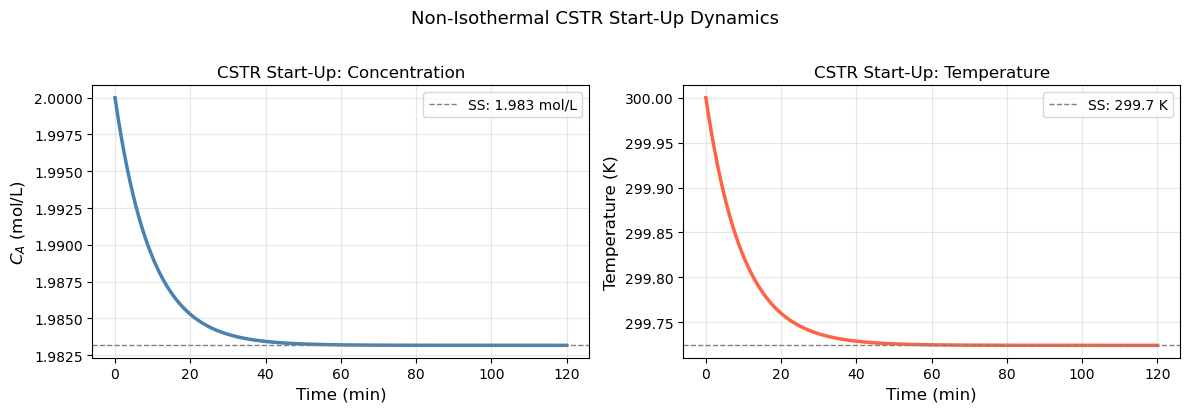

In [13]:
# ── CSTR start-up dynamics ───────────────────────────────────────────────────

# Reactor parameters
Q      = 10.0        # L/min   — volumetric flow rate
V      = 100.0       # L       — reactor volume  → τ = V/Q = 10 min
CA_in  = 2.0         # mol/L   — feed concentration
T_in   = 300.0       # K       — feed temperature
T_c    = 290.0       # K       — cooling jacket temperature
UA     = 2000.0      # J/(min·K)
rho_Cp_cstr = 4000.0 # J/(L·K)

# Kinetics (same Arrhenius as batch)
A_cstr = 1.0e10
Ea_cstr = 75_000.0
dH_cstr = -50_000.0

def cstr_startup(t, y):
    C_A, T = y
    k_T    = A_cstr * np.exp(-Ea_cstr / (R_gas * T))
    tau_   = V / Q

    dCA_dt = (CA_in - C_A) / tau_ - k_T * C_A
    dT_dt  = ((T_in - T) / tau_
              + (-dH_cstr) * k_T * C_A / rho_Cp_cstr
              - UA * (T - T_c) / (V * rho_Cp_cstr))
    return [dCA_dt, dT_dt]

t_eval_cstr = np.linspace(0, 120, 1200)

# Start cold and empty (feed conditions as IC)
sol_cstr = solve_ivp(cstr_startup,
                     t_span=(0, 120),
                     y0=[CA_in, T_in],   # start with feed filling reactor
                     method='Radau',
                     t_eval=t_eval_cstr,
                     rtol=1e-8, atol=1e-10)

# Approximate steady state (last 5 points average)
CA_ss = np.mean(sol_cstr.y[0, -5:])
T_ss  = np.mean(sol_cstr.y[1, -5:])
X_ss  = (CA_in - CA_ss) / CA_in
print(f"Steady-state C_A ≈ {CA_ss:.4f} mol/L")
print(f"Steady-state T   ≈ {T_ss:.2f} K")
print(f"Steady-state conversion X_A ≈ {X_ss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sol_cstr.t, sol_cstr.y[0], 'steelblue', linewidth=2.5)
axes[0].axhline(CA_ss, color='gray', linestyle='--', linewidth=1, label=f'SS: {CA_ss:.3f} mol/L')
axes[0].set_xlabel('Time (min)', fontsize=12)
axes[0].set_ylabel('$C_A$ (mol/L)', fontsize=12)
axes[0].set_title('CSTR Start-Up: Concentration', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(sol_cstr.t, sol_cstr.y[1], 'tomato', linewidth=2.5)
axes[1].axhline(T_ss, color='gray', linestyle='--', linewidth=1, label=f'SS: {T_ss:.1f} K')
axes[1].set_xlabel('Time (min)', fontsize=12)
axes[1].set_ylabel('Temperature (K)', fontsize=12)
axes[1].set_title('CSTR Start-Up: Temperature', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Non-Isothermal CSTR Start-Up Dynamics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Chapter 18 Summary

| Concept | Code | Notes |
|---------|------|-------|
| Define ODE | `def f(t, y): return [...]` | `y` is always a list/array; return same shape |
| Solve ODE | `solve_ivp(f, (t0,tf), y0)` | Default method: `'RK45'` |
| Save output times | `t_eval=np.linspace(t0, tf, N)` | Otherwise solver picks its own points |
| Pass parameters | `args=(p1, p2)` | Add params to `f(t, y, p1, p2)` |
| Access solution | `sol.t`, `sol.y[i]` | Row `i` of `sol.y` is variable `i` |
| Stiff problem | `method='Radau'` or `'BDF'` | When RK45 is very slow or takes tiny steps |
| Euler's method | `y_next = y + h * f(t, y)` | For understanding only — don't use in practice |
| System of ODEs | `y0=[C_A0, T0, ...]` | One IC per equation |

**Workflow for any ODE problem:**
1. Identify state variables $\to$ one entry in `y` per variable
2. Write each $\frac{dy_i}{dt}$ as a function of `t` and `y`
3. Collect into `def rhs(t, y): return [dy1, dy2, ...]`
4. Call `solve_ivp(rhs, (t0, tf), y0, t_eval=...)`
5. Check `sol.success` and verify physics (mass balance, energy balance)
6. If slow or failing, try `method='Radau'`

**Key insight:** every ODE solver is doing essentially the same thing as Euler's method — just with smarter, higher-order estimates of the slope at each step. The core idea is always: march forward from the initial condition using the known rate of change.